In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 假设我们已经有了带有聚类标签的用户数据
# 如果还没有，先运行聚类分析
# 这里假设 customer_features 已经包含了 'Cluster' 列

# 加载数据（如果已保存）
try:
    customer_features = pd.read_csv('customer_clusters_simple.csv')
    print(f"加载用户数据: {customer_features.shape}")
except:
    print("请先运行聚类分析")
    # 如果还没有数据，这里需要先运行聚类代码
    exit()

plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False  # 解决负号显示问题

# 1. 为每个用户创建个性化画像特征
def create_individual_profiles(df):
    """为每个用户创建详细的个性化画像"""
    
    profiles = []
    
    for idx, row in df.iterrows():
        # 基本特征
        profile = {
            'Customer_ID': row['Customer ID'],
            'Customer_Name': row.get('Customer Name', 'Unknown'),
            'Cluster': row['Cluster'],
            
            # 关键指标
            'Total_Sales': row['Total_Sales'],
            'Total_Orders': row['Total_Orders'],
            'Avg_Order_Value': row['Avg_Order_Value'],
            'Customer_Lifetime': row['Customer_Lifetime_Days'],
            'Purchase_Frequency': row['Purchase_Frequency'],
            'Profit_Margin': row['Profit_Margin'],
            'Last_Purchase_Days_Ago': row['Days_Since_Last_Purchase'],
            'Engagement_Score': row['Total_Engagement_Score'],
            
            # 人口统计
            'Segment': row['Segment'],
            'Region': row['Region'],
            'Country': row['Country'],
            'Gender': row['Gender'],
            'Age': row['Age'],
            'Education': row['Education'],
            'Marital_Status': row['Marital Status'],
            
            # 产品偏好
            'Favorite_Product': row.get('Favorite_Product', 'Unknown'),
            'Unique_Products_Bought': row['Unique_Products_Purchased']
        }
        
        profiles.append(profile)
    
    return pd.DataFrame(profiles)

# 创建个性化画像
individual_profiles = create_individual_profiles(customer_features)
print(f"个性化画像创建完成: {individual_profiles.shape}")


加载用户数据: (795, 60)
个性化画像创建完成: (795, 20)


In [10]:
# 2. 计算相对排名和百分位数
def calculate_percentiles_and_rankings(df):
    """计算每个用户在各项指标上的排名和百分位数"""
    
    result_df = df.copy()
    
    # 定义要计算排名的关键指标
    metrics = [
        'Total_Sales',
        'Total_Orders', 
        'Avg_Order_Value',
        'Purchase_Frequency',
        'Profit_Margin',
        'Engagement_Score',
        'Customer_Lifetime'
    ]
    
    # 为每个指标计算排名和百分位数
    for metric in metrics:
        if metric in df.columns:
            # 百分位数 (0-100)
            result_df[f'{metric}_Percentile'] = df[metric].rank(pct=True) * 100
            
            # 排名
            result_df[f'{metric}_Rank'] = df[metric].rank(ascending=False, method='min')
            
            # 评级 (A, B, C, D, E)
            def get_grade(percentile):
                if percentile >= 80:
                    return 'A'
                elif percentile >= 60:
                    return 'B'
                elif percentile >= 40:
                    return 'C'
                elif percentile >= 20:
                    return 'D'
                else:
                    return 'E'
            
            result_df[f'{metric}_Grade'] = result_df[f'{metric}_Percentile'].apply(get_grade)
            
            # 与平均值的比较
            overall_mean = df[metric].mean()
            result_df[f'{metric}_vs_Mean'] = ((df[metric] - overall_mean) / overall_mean * 100).round(1)
    
    return result_df

# 计算排名和百分位数
individual_profiles_with_rankings = calculate_percentiles_and_rankings(individual_profiles)
print(f"排名计算完成")

# 3. 创建用户画像描述
def create_personalized_description(row):
    """为每个用户创建个性化的文字描述"""
    
    descriptions = []
    
    # 基本描述
    descriptions.append(f"客户 {row['Customer_Name']} ({row['Customer_ID']}) 属于第 {row['Cluster']} 类用户群体。")
    
    # 价值描述
    if row['Total_Sales_Percentile'] >= 80:
        descriptions.append("这是一位高价值客户，总消费金额排在前20%。")
    elif row['Total_Sales_Percentile'] >= 60:
        descriptions.append("这是一位中高价值客户，消费金额较为可观。")
    elif row['Total_Sales_Percentile'] >= 40:
        descriptions.append("这是一位中等价值客户。")
    else:
        descriptions.append("这是一位低价值客户，有较大的提升空间。")
    
    # 忠诚度描述
    if row['Customer_Lifetime'] > 365:
        descriptions.append("客户关系已维持超过1年，属于长期忠实客户。")
    elif row['Customer_Lifetime'] > 180:
        descriptions.append("客户关系已维持半年以上，忠诚度较高。")
    
    # 活跃度描述
    if row['Last_Purchase_Days_Ago'] <= 30:
        descriptions.append("近期活跃，最近30天内有过购买。")
    elif row['Last_Purchase_Days_Ago'] <= 90:
        descriptions.append("较为活跃，最近90天内有过购买。")
    elif row['Last_Purchase_Days_Ago'] <= 180:
        descriptions.append("活跃度一般，最近半年内有过购买。")
    else:
        descriptions.append("活跃度较低，需要重新激活。")
    
    # 购买行为描述
    if row['Avg_Order_Value_Percentile'] >= 80:
        descriptions.append("购买力强，平均订单价值较高。")
    
    if row['Purchase_Frequency_Percentile'] >= 80:
        descriptions.append("购买频率高，复购行为明显。")
    
    # 互动描述
    if row['Engagement_Score_Percentile'] >= 80:
        descriptions.append("互动积极，经常浏览、点赞和分享产品。")
    
    # 产品偏好
    if 'Favorite_Product' in row and row['Favorite_Product'] != 'Unknown':
        descriptions.append(f"最常购买的产品是：{row['Favorite_Product']}。")
    
    if row['Unique_Products_Bought'] >= 5:
        descriptions.append("产品涉猎广泛，购买过多种不同类型的产品。")
    
    # 建议
    suggestions = []
    
    if row['Last_Purchase_Days_Ago'] > 90:
        suggestions.append("发送再营销邮件和专属优惠")
    
    if row['Total_Sales_Percentile'] >= 80:
        suggestions.append("提供VIP专属服务和优先配送")
    
    if row['Purchase_Frequency_Percentile'] >= 80:
        suggestions.append("推荐忠诚度计划和定期购服务")
    
    if row['Engagement_Score_Percentile'] >= 80:
        suggestions.append("邀请参与产品评测和新品试用")
    
    if suggestions:
        descriptions.append(f"营销建议：{'；'.join(suggestions)}。")
    
    return " ".join(descriptions)

# 为每个用户生成描述
print("\n正在为每个用户生成个性化描述...")
individual_profiles_with_rankings['Personalized_Description'] = individual_profiles_with_rankings.apply(
    create_personalized_description, axis=1
)

排名计算完成

正在为每个用户生成个性化描述...


In [11]:
# 4. 创建详细的数据分析卡片
def create_user_analysis_card(user_data):
    """为单个用户创建详细的分析卡片"""
    
    user_id = user_data['Customer_ID']
    user_name = user_data['Customer_Name']
    
    print(f"\n{'='*80}")
    print(f"客户分析卡片: {user_name} ({user_id})")
    print(f"{'='*80}")
    
    # 基础信息
    print(f"\n📋 基础信息:")
    print(f"   客户类型: {user_data['Segment']}")
    print(f"   所在地区: {user_data['Region']}, {user_data['Country']}")
    print(f"   性别: {user_data['Gender']} | 年龄: {user_data['Age']}")
    print(f"   教育程度: {user_data['Education']} | 婚姻状况: {user_data['Marital_Status']}")
    
    # 关键指标
    print(f"\n📊 关键指标:")
    print(f"   总销售额: ${user_data['Total_Sales']:,.2f} (排名: {user_data['Total_Sales_Rank']:.0f}/{len(individual_profiles)}，百分位: {user_data['Total_Sales_Percentile']:.1f}%，评级: {user_data['Total_Sales_Grade']})")
    print(f"   总订单数: {user_data['Total_Orders']:.0f} (排名: {user_data['Total_Orders_Rank']:.0f}/{len(individual_profiles)}，百分位: {user_data['Total_Orders_Percentile']:.1f}%)")
    print(f"   平均订单价值: ${user_data['Avg_Order_Value']:,.2f} (排名: {user_data['Avg_Order_Value_Rank']:.0f}/{len(individual_profiles)}，百分位: {user_data['Avg_Order_Value_Percentile']:.1f}%)")
    print(f"   利润率: {user_data['Profit_Margin']*100:.1f}% (排名: {user_data['Profit_Margin_Rank']:.0f}/{len(individual_profiles)})")
    
    # 行为指标
    print(f"\n🎯 行为指标:")
    print(f"   客户生命周期: {user_data['Customer_Lifetime']:.0f} 天")
    print(f"   距离上次购买: {user_data['Last_Purchase_Days_Ago']:.0f} 天")
    print(f"   购买频率: {user_data['Purchase_Frequency']:.4f} (每天购买次数)")
    print(f"   互动评分: {user_data['Engagement_Score']:.1f} (排名: {user_data['Engagement_Score_Rank']:.0f}/{len(individual_profiles)})")
    
    # 产品偏好
    print(f"\n🛒 产品偏好:")
    print(f"   最常购买: {user_data['Favorite_Product']}")
    print(f"   购买产品种类: {user_data['Unique_Products_Bought']:.0f} 种")
    
    # 所属聚类
    print(f"\n🏷️  用户分类:")
    print(f"   所属聚类: {user_data['Cluster']}")
    
    # 相对表现
    print(f"\n📈 相对表现 (与平均值相比):")
    print(f"   总销售额: {user_data['Total_Sales_vs_Mean']:+.1f}%")
    print(f"   平均订单价值: {user_data['Avg_Order_Value_vs_Mean']:+.1f}%")
    print(f"   购买频率: {user_data['Purchase_Frequency_vs_Mean']:+.1f}%")
    
    # 个性化描述
    print(f"\n💡 综合描述:")
    print(f"   {user_data['Personalized_Description']}")
    
    print(f"{'='*80}")

# 5. 创建可视化图表
def create_user_visualization(user_data, all_users_data):
    """为单个用户创建可视化图表"""
    
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    fig.suptitle(f'客户分析: {user_data["Customer_Name"]} ({user_data["Customer_ID"]})', fontsize=16)
    
    # 1. 雷达图 - 关键指标对比
    ax1 = axes[0, 0]
    metrics_radar = ['Total_Sales', 'Total_Orders', 'Avg_Order_Value', 'Purchase_Frequency', 'Profit_Margin']
    user_values = []
    avg_values = []
    
    for metric in metrics_radar:
        user_values.append(user_data[metric] / all_users_data[metric].max())
        avg_values.append(all_users_data[metric].mean() / all_users_data[metric].max())
    
    angles = np.linspace(0, 2*np.pi, len(metrics_radar), endpoint=False).tolist()
    user_values += user_values[:1]
    avg_values += avg_values[:1]
    angles += angles[:1]
    
    ax1 = plt.subplot(2, 2, 1, polar=True)
    ax1.plot(angles, user_values, 'o-', linewidth=2, label='该用户')
    ax1.plot(angles, avg_values, 'o-', linewidth=2, label='平均用户')
    ax1.fill(angles, user_values, alpha=0.25)
    ax1.set_xticks(angles[:-1])
    ax1.set_xticklabels(['销售额', '订单数', '订单价值', '购买频率', '利润率'])
    ax1.legend(loc='upper right')
    ax1.set_title('关键指标雷达图')
    
    # 2. 条形图 - 排名对比
    ax2 = axes[0, 1]
    metrics_rank = ['Total_Sales', 'Avg_Order_Value', 'Purchase_Frequency', 'Engagement_Score']
    rankings = [user_data[f'{m}_Percentile'] for m in metrics_rank]
    
    bars = ax2.barh(metrics_rank, rankings)
    ax2.set_xlabel('百分位数 (%)')
    ax2.set_title('各项指标排名')
    ax2.set_xlim(0, 100)
    
    # 添加数值标签
    for bar, rank in zip(bars, rankings):
        ax2.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2,
                f'{rank:.1f}%', va='center')
    
    # 3. 时间线图
    ax3 = axes[1, 0]
    timeline_data = {
        '客户注册': 0,
        '首次购买': user_data['Customer_Lifetime'] - user_data['Last_Purchase_Days_Ago'],
        '最近购买': user_data['Customer_Lifetime']
    }
    
    ax3.barh(list(timeline_data.keys()), list(timeline_data.values()))
    ax3.set_xlabel('天数')
    ax3.set_title('客户生命周期时间线')
    
    # 4. 对比散点图
    ax4 = axes[1, 1]
    ax4.scatter(all_users_data['Total_Orders'], all_users_data['Total_Sales'], 
               alpha=0.3, label='所有用户')
    ax4.scatter(user_data['Total_Orders'], user_data['Total_Sales'], 
               color='red', s=200, label='该用户', marker='*')
    ax4.set_xlabel('总订单数')
    ax4.set_ylabel('总销售额 ($)')
    ax4.set_title('订单 vs 销售额对比')
    ax4.legend()
    ax4.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

               电子商务用户个性化画像分析系统

选项1: 分析特定用户
选项2: 随机分析3个用户示例
选项3: 保存所有用户画像
选项4: 生成摘要报告
分析 3 个用户...

客户分析卡片: Fisher Carlisle (LE-00307)

📋 基础信息:
   客户类型: Corporate
   所在地区: East, United States
   性别: Female | 年龄: 33
   教育程度: Bachelor | 婚姻状况: Single

📊 关键指标:
   总销售额: $7,998.00 (排名: 657/795，百分位: 17.5%，评级: E)
   总订单数: 49 (排名: 691/795，百分位: 12.5%)
   平均订单价值: $163.22 (排名: 195/795，百分位: 75.5%)
   利润率: 46.7% (排名: 361/795)

🎯 行为指标:
   客户生命周期: 1048 天
   距离上次购买: 2 天
   购买频率: 0.0468 (每天购买次数)
   互动评分: 108.0 (排名: 378/795)

🛒 产品偏好:
   最常购买: Casula Shoes
   购买产品种类: 25 种

🏷️  用户分类:
   所属聚类: 0

📈 相对表现 (与平均值相比):
   总销售额: -20.7%
   平均订单价值: +4.4%
   购买频率: -23.1%

💡 综合描述:
   客户 Fisher Carlisle (LE-00307) 属于第 0 类用户群体。 这是一位低价值客户，有较大的提升空间。 客户关系已维持超过1年，属于长期忠实客户。 近期活跃，最近30天内有过购买。 最常购买的产品是：Casula Shoes。 产品涉猎广泛，购买过多种不同类型的产品。


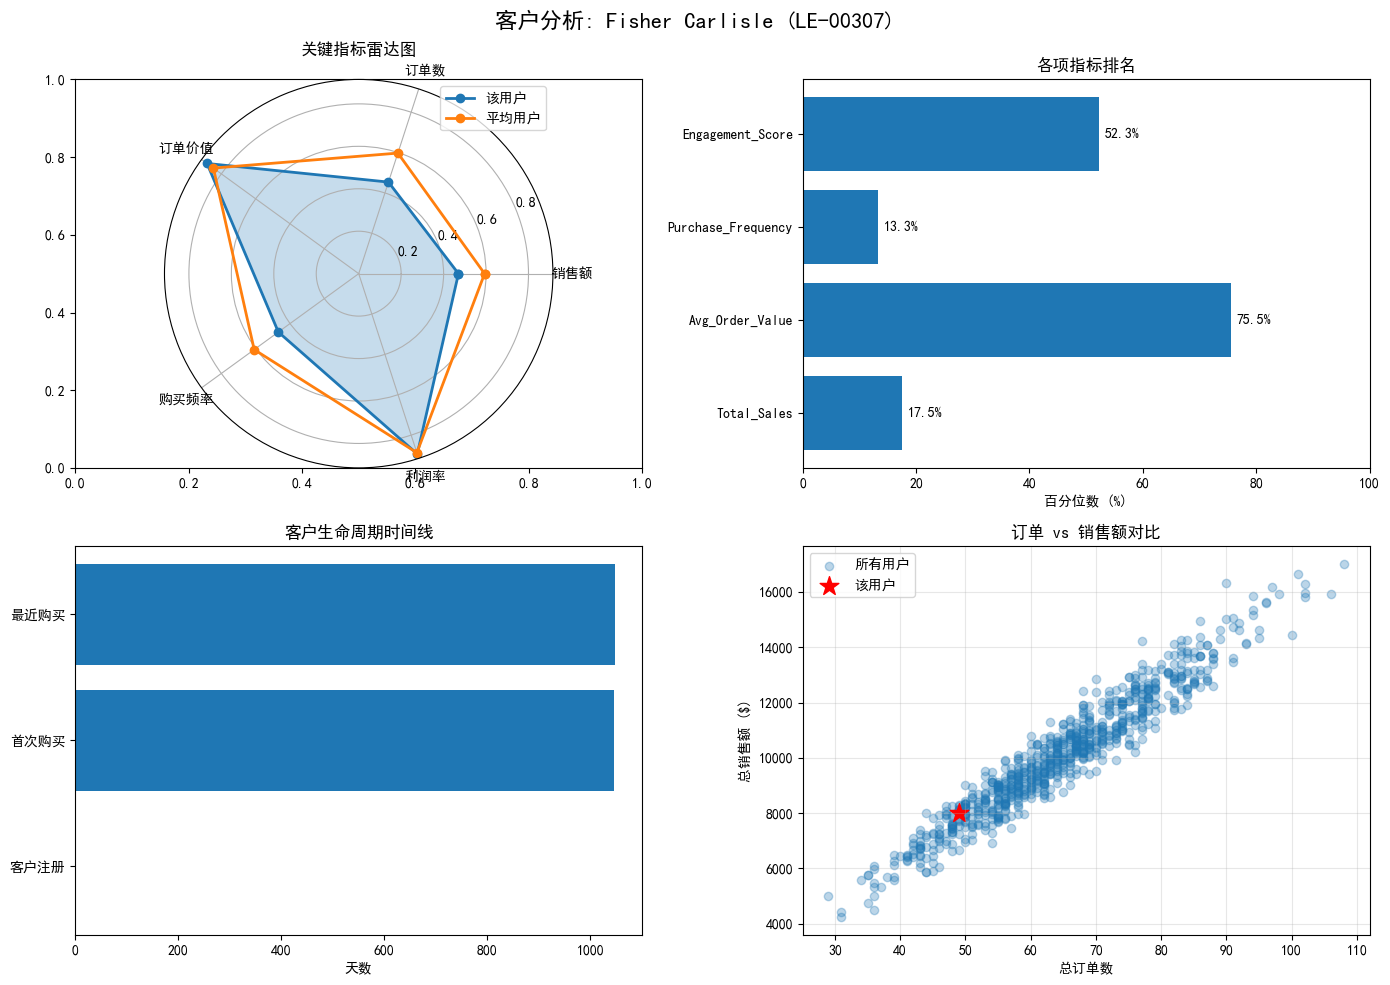


客户分析卡片: Peterson Blumstein (IN-00585)

📋 基础信息:
   客户类型: Corporate
   所在地区: South, Italy
   性别: Male | 年龄: 22
   教育程度: Bachelor | 婚姻状况: Single

📊 关键指标:
   总销售额: $9,106.00 (排名: 518/795，百分位: 35.0%，评级: D)
   总订单数: 62 (排名: 433/795，百分位: 44.0%)
   平均订单价值: $146.87 (排名: 676/795，百分位: 15.1%)
   利润率: 44.5% (排名: 650/795)

🎯 行为指标:
   客户生命周期: 1048 天
   距离上次购买: 2 天
   购买频率: 0.0592 (每天购买次数)
   互动评分: 74.0 (排名: 648/795)

🛒 产品偏好:
   最常购买: Dinner Crockery
   购买产品种类: 29 种

🏷️  用户分类:
   所属聚类: 0

📈 相对表现 (与平均值相比):
   总销售额: -9.8%
   平均订单价值: -6.1%
   购买频率: -2.7%

💡 综合描述:
   客户 Peterson Blumstein (IN-00585) 属于第 0 类用户群体。 这是一位低价值客户，有较大的提升空间。 客户关系已维持超过1年，属于长期忠实客户。 近期活跃，最近30天内有过购买。 最常购买的产品是：Dinner Crockery。 产品涉猎广泛，购买过多种不同类型的产品。


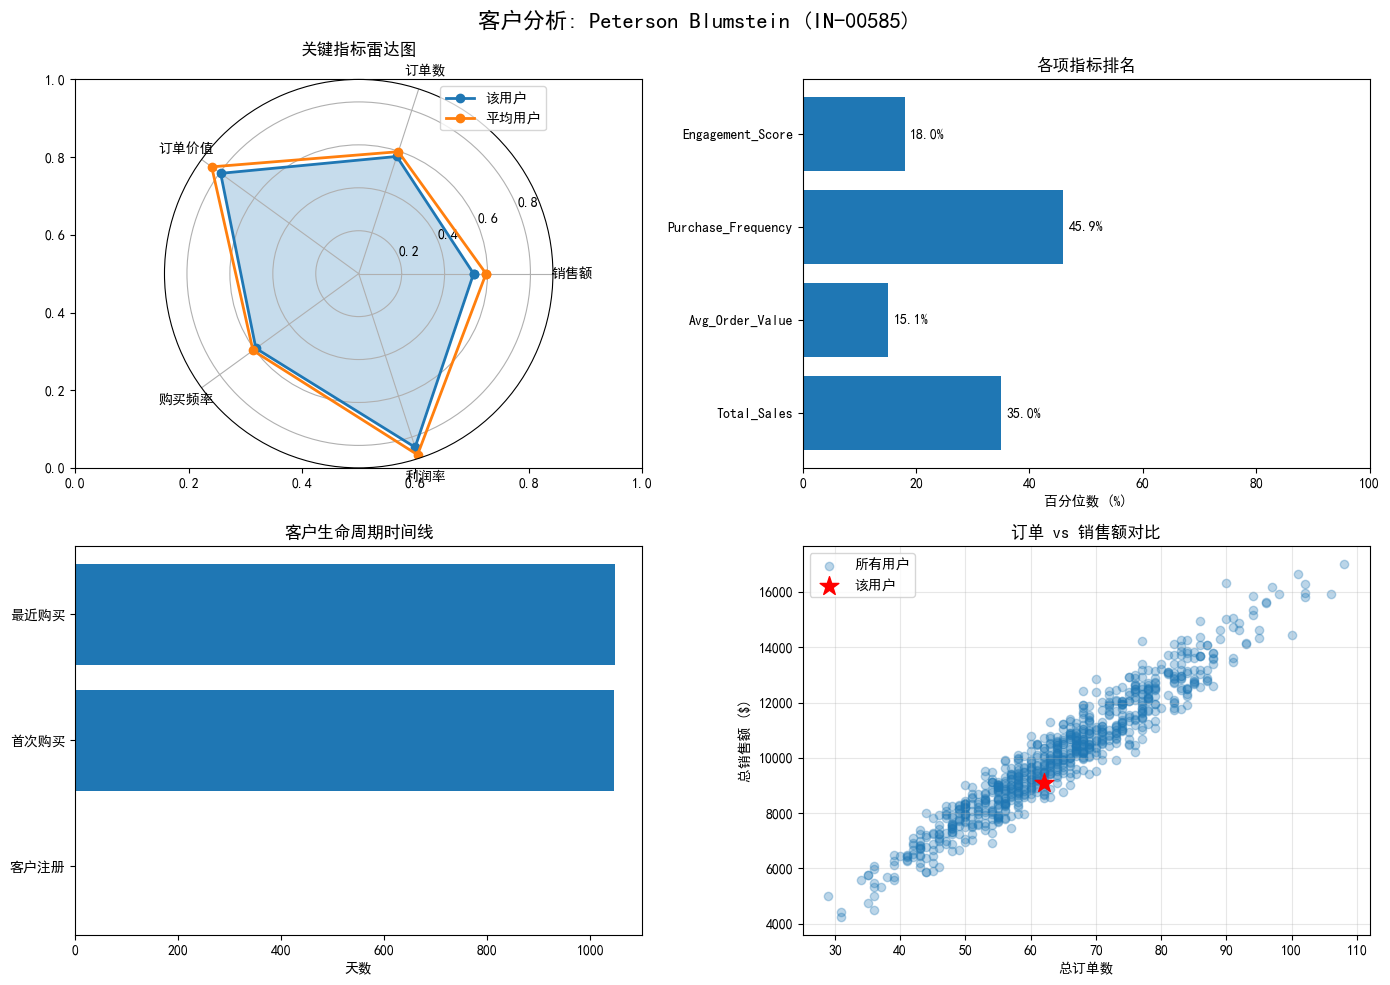


客户分析卡片: Cruz Carroll (LL-001161)

📋 基础信息:
   客户类型: Consumer
   所在地区: Central, El Salvador
   性别: Female | 年龄: 30
   教育程度: Master | 婚姻状况: Married

📊 关键指标:
   总销售额: $10,589.00 (排名: 313/795，百分位: 60.8%，评级: B)
   总订单数: 64 (排名: 386/795，百分位: 50.1%)
   平均订单价值: $165.45 (排名: 126/795，百分位: 84.3%)
   利润率: 46.5% (排名: 398/795)

🎯 行为指标:
   客户生命周期: 1042 天
   距离上次购买: 35 天
   购买频率: 0.0614 (每天购买次数)
   互动评分: 142.0 (排名: 190/795)

🛒 产品偏好:
   最常购买: Fossil Watch
   购买产品种类: 22 种

🏷️  用户分类:
   所属聚类: 0

📈 相对表现 (与平均值相比):
   总销售额: +4.9%
   平均订单价值: +5.8%
   购买频率: +0.9%

💡 综合描述:
   客户 Cruz Carroll (LL-001161) 属于第 0 类用户群体。 这是一位中高价值客户，消费金额较为可观。 客户关系已维持超过1年，属于长期忠实客户。 较为活跃，最近90天内有过购买。 购买力强，平均订单价值较高。 最常购买的产品是：Fossil Watch。 产品涉猎广泛，购买过多种不同类型的产品。


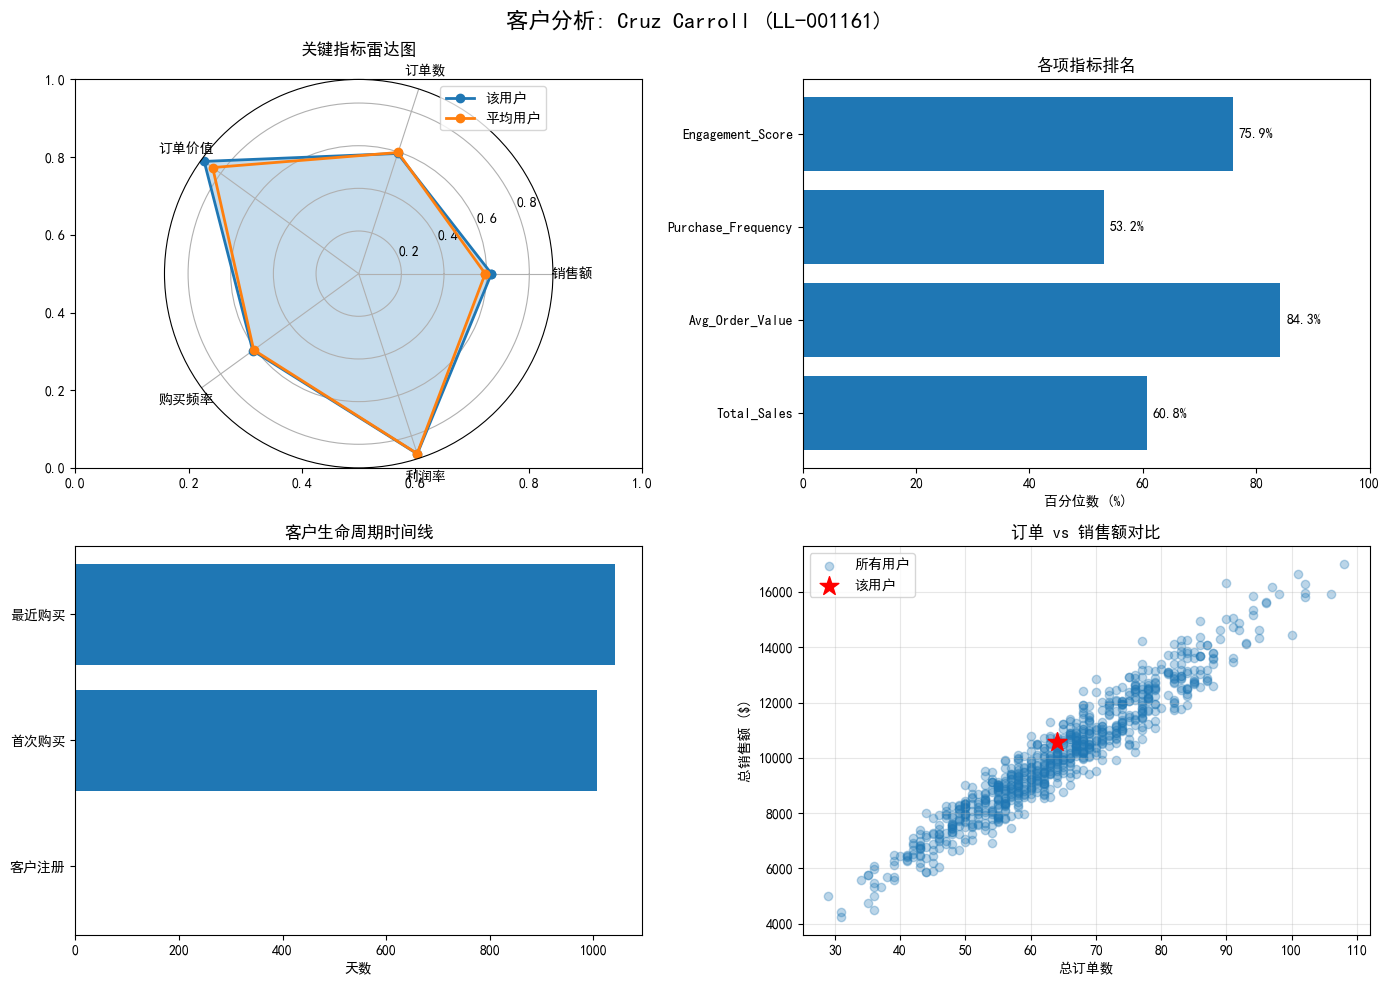


分析完成！


In [12]:
# 6. 为特定用户生成分析
def analyze_specific_users(user_ids=None, n_samples=3):
    """分析特定用户或随机抽样用户"""
    
    if user_ids:
        # 分析指定用户
        selected_users = individual_profiles_with_rankings[
            individual_profiles_with_rankings['Customer_ID'].isin(user_ids)
        ]
    else:
        # 随机选择几个用户分析
        selected_users = individual_profiles_with_rankings.sample(min(n_samples, len(individual_profiles_with_rankings)))
    
    print(f"分析 {len(selected_users)} 个用户...")
    
    for idx, user_row in selected_users.iterrows():
        # 生成分析卡片
        create_user_analysis_card(user_row)
        
        # 生成可视化
        create_user_visualization(user_row, individual_profiles_with_rankings)
        
        # 询问是否继续
        if idx < len(selected_users) - 1:
            continue_input = input("\n按Enter继续分析下一个用户，或输入q退出: ")
            if continue_input.lower() == 'q':
                break
    
    return selected_users

# 7. 保存所有用户的详细画像
def save_all_user_profiles(profiles_df, output_file='all_user_profiles_detailed.csv'):
    """保存所有用户的详细画像到CSV"""
    
    # 选择要保存的列
    columns_to_save = [
        'Customer_ID', 'Customer_Name', 'Cluster', 
        'Segment', 'Region', 'Country', 'Gender', 'Age', 
        'Total_Sales', 'Total_Orders', 'Avg_Order_Value',
        'Customer_Lifetime', 'Purchase_Frequency', 'Profit_Margin',
        'Last_Purchase_Days_Ago', 'Engagement_Score',
        'Favorite_Product', 'Unique_Products_Bought',
        'Total_Sales_Percentile', 'Total_Sales_Grade',
        'Avg_Order_Value_Percentile', 'Avg_Order_Value_Grade',
        'Purchase_Frequency_Percentile', 'Purchase_Frequency_Grade',
        'Personalized_Description'
    ]
    
    # 只保存存在的列
    existing_columns = [col for col in columns_to_save if col in profiles_df.columns]
    profiles_to_save = profiles_df[existing_columns].copy()
    
    # 保存
    profiles_to_save.to_csv(output_file, index=False, encoding='utf-8')
    print(f"\n所有用户画像已保存到: {output_file}")
    print(f"共保存 {len(profiles_to_save)} 个用户的详细画像")
    
    return profiles_to_save

# 8. 创建用户画像摘要报告
def create_user_profile_summary_report(profiles_df, output_file='user_profiles_summary.txt'):
    """创建用户画像摘要报告"""
    
    with open(output_file, 'w', encoding='utf-8') as f:
        f.write("="*80 + "\n")
        f.write("                   电子商务用户画像分析报告\n")
        f.write("="*80 + "\n\n")
        
        f.write(f"分析时间: {pd.Timestamp.now().strftime('%Y-%m-%d %H:%M:%S')}\n")
        f.write(f"总用户数: {len(profiles_df)}\n")
        
        # 聚类分布
        f.write("\n一、用户聚类分布\n")
        f.write("-"*40 + "\n")
        cluster_dist = profiles_df['Cluster'].value_counts().sort_index()
        for cluster, count in cluster_dist.items():
            percentage = count / len(profiles_df) * 100
            f.write(f"聚类 {cluster}: {count} 用户 ({percentage:.1f}%)\n")
        
        # 高价值用户分析
        f.write("\n二、高价值用户分析\n")
        f.write("-"*40 + "\n")
        high_value_users = profiles_df[profiles_df['Total_Sales_Percentile'] >= 80]
        f.write(f"高价值用户数 (前20%): {len(high_value_users)}\n")
        if not high_value_users.empty:
            f.write("部分高价值用户:\n")
            for _, user in high_value_users.head(5).iterrows():
                f.write(f"  • {user['Customer_Name']} ({user['Customer_ID']}): "
                       f"总销售额 ${user['Total_Sales']:,.2f}, "
                       f"平均订单价值 ${user['Avg_Order_Value']:,.2f}\n")
        
        # 高流失风险用户
        f.write("\n三、高流失风险用户\n")
        f.write("-"*40 + "\n")
        high_churn_risk = profiles_df[profiles_df['Last_Purchase_Days_Ago'] > 90]
        f.write(f"90天未购买用户数: {len(high_churn_risk)}\n")
        
        # 高互动用户
        f.write("\n四、高互动用户\n")
        f.write("-"*40 + "\n")
        high_engagement = profiles_df[profiles_df['Engagement_Score_Percentile'] >= 80]
        f.write(f"高互动用户数 (前20%): {len(high_engagement)}\n")
        
        # 用户特征统计
        f.write("\n五、用户特征统计\n")
        f.write("-"*40 + "\n")
        f.write(f"平均总销售额: ${profiles_df['Total_Sales'].mean():,.2f}\n")
        f.write(f"平均订单数: {profiles_df['Total_Orders'].mean():.1f}\n")
        f.write(f"平均订单价值: ${profiles_df['Avg_Order_Value'].mean():,.2f}\n")
        f.write(f"平均客户生命周期: {profiles_df['Customer_Lifetime'].mean():.0f} 天\n")
        f.write(f"平均购买频率: {profiles_df['Purchase_Frequency'].mean():.4f}\n")
        
        # 建议
        f.write("\n六、总体建议\n")
        f.write("-"*40 + "\n")
        f.write("1. 重点关注高价值用户，提供个性化服务和专属优惠\n")
        f.write("2. 对90天未购买用户实施再营销策略\n")
        f.write("3. 利用高互动用户进行口碑营销和产品评测\n")
        f.write("4. 针对不同聚类用户设计差异化的营销活动\n")
    
    print(f"用户画像摘要报告已保存到: {output_file}")

# 9. 主程序：执行分析
def main():
    """主分析程序"""
    
    print("="*80)
    print("               电子商务用户个性化画像分析系统")
    print("="*80)
    
    # 选项1：分析特定用户
    print("\n选项1: 分析特定用户")
    print("选项2: 随机分析3个用户示例")
    print("选项3: 保存所有用户画像")
    print("选项4: 生成摘要报告")
    
    choice = input("\n请选择 (1-4): ")
    
    if choice == '1':
        # 显示部分用户ID供选择
        print("\n部分用户ID示例:")
        sample_users = individual_profiles_with_rankings[['Customer_ID', 'Customer_Name', 'Total_Sales']].head(10)
        print(sample_users.to_string(index=False))
        
        # 让用户输入要分析的ID
        user_input = input("\n请输入要分析的用户ID (用逗号分隔多个ID): ")
        user_ids = [id.strip() for id in user_input.split(',') if id.strip()]
        
        if user_ids:
            analyzed_users = analyze_specific_users(user_ids)
        else:
            print("未输入有效用户ID，改为随机分析3个用户")
            analyzed_users = analyze_specific_users(n_samples=3)
    
    elif choice == '2':
        analyzed_users = analyze_specific_users(n_samples=3)
    
    elif choice == '3':
        saved_profiles = save_all_user_profiles(individual_profiles_with_rankings)
        print(f"\n已保存 {len(saved_profiles)} 个用户的详细画像")
        
        # 显示保存文件的前几行
        print("\n保存文件预览:")
        print(saved_profiles.head().to_string())
    
    elif choice == '4':
        create_user_profile_summary_report(individual_profiles_with_rankings)
    
    else:
        print("无效选择")
    
    print("\n分析完成！")

# 运行主程序
if __name__ == "__main__":
    main()